# Phase 3: what the camera can see

`01_inspect_scene.ipynb` shows the constructed ground truth. This one shows what a single
view of it actually returns.

Three things are separate on purpose and it is worth keeping them separate while reading:

| | what it is | where it lives |
|---|---|---|
| `visible_from_cam` | **geometry**: framed, in range, front-facing, unoccluded | stored in `cloud.npz` |
| sensor dropout | grazing incidence, blind zone — the matcher failing on a surface it *can* see | `noise.apply`, not stored |
| `occluded_fraction` | per seam: hidden by **another part**. Near-binary | stored per seam |
| `in_frame_fraction` | per seam: inside the image and past the blind zone. **Graded** | stored per seam |
| `visible_fraction` | per seam: their conjunction — what the sensor returns | stored per seam |

The last two exist because occlusion and framing are different physics. A convex occluder
shadows a straight seam all-or-nothing; the image edge cuts it *partway*. Splitting them is
what makes an error-vs-visibility plot a curve rather than two points.

Occlusion stays a statement about geometry, so it is comparable across the three sensor
profiles instead of being confounded with them.

**Tier 1 omits scenes with no visible seam.** Not relabels — omits. A "no seam" class would
encode joint type and camera placement rather than anything about the task: the lower toe of
a lap joint is *never* visible from above a table, so the label would be predictable from
the wrong evidence. Tier 1 keeps the occlusion numbers anyway; tier 2 is what uses them.

In [14]:
import sys, numpy as np
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/

import matplotlib.pyplot as plt
from weldgen.config import SENSOR_PROFILES, load_config
from weldgen.scene import (NoSeamsFound, NoVisibleSeams, SceneRejected,
                           generate_scene)
from weldgen.scene_curved import generate_curved_scene

JOINT = "T"          # plate mode: T | corner | butt | lap | edge
SEED  = 12

# Phase 6: read the playground preset and follow its flags. Uncomment `seam_families`
# there and the whole notebook switches to the curved pipeline (JOINT is then ignored -
# the family draw decides the joint type).
cfg = load_config("../configs/playground.yaml")
CURVED = bool(cfg.get("seam_families"))
gen = generate_curved_scene if CURVED else generate_scene
if not CURVED:
    cfg["joint_type"] = [JOINT]
cfg["sensor_profiles"] = ["d435i"]

# The omission policy means a seed is not guaranteed to yield a scene, so walk forward
# until one does. What gets skipped, and why, is printed - that IS the policy in action.
scene = arrays = None
for seed in range(SEED, SEED + 80):
    try:
        scene, arrays = gen(cfg, seed)
        break
    except SceneRejected as e:
        print(f"  seed {seed} omitted - {type(e).__name__}")
assert scene is not None, "no emitting seed in 80 tries"

print(f"\nusing seed {seed}")
print("joint    ", scene["joint"]["type"], "| quality",
      scene["joint"]["quality_level"],
      ("| family " + scene["joint"]["seam_family"]) if CURVED else
      ("| prep " + scene["joint"].get("prep", "square")))
print("profile  ", scene["noise_model"]["profile"],
      f"| blind zone below {scene['noise_model']['min_z_mm']:.0f} mm")
print("camera   ", f"standoff {scene['camera']['standoff_mm']:.0f} mm,",
      f"elevation {scene['camera']['elevation_deg']:.1f} deg")
print("cloud    ", scene["cloud"]["n_points"], "points,",
      f"{100 * arrays['cloud.npz:visible_from_cam'].mean():.1f}% visible")


using seed 12
joint     T | quality C | family saddle
profile   d435i | blind zone below 280 mm
camera    standoff 300 mm, elevation 48.6 deg
cloud     23650 points, 20.7% visible


## Per-seam verdict

Rejected candidates keep their occlusion figure too. They are negatives, not absences —
a baseline will return them, so knowing whether the camera could even see them matters.

In [15]:
# `weldable` is reachability; `matches_joint_type` is taxonomy. PRIMARY is both, and it
# is what supervision targets. An off-class seam is a real weld this joint type does not
# claim. Curved seams add `clear_fraction` (how much of the seam the torch cone clears -
# the bore gate's graded sibling); plates leave it null.
print(f'{"id":>3} {"face pair":<24} {"class":<9} {"len":>8} {"occl":>6} {"frame":>6} '
      f'{"vis":>5} {"clear":>6}  verdict')
for s in scene["seams"]:
    pair = f'{s["face_pair"][0]}/{s["face_pair"][1]}'
    if s["weldable"] and s["matches_joint_type"]:
        verdict = "PRIMARY (ground truth)"
    elif s["weldable"]:
        verdict = "weldable, off-class for this joint type"
    else:
        verdict = f'rejected: {s["reject_reason"]}'
    if s.get("closed"):
        verdict += "  [closed]"
    clear = ("  --" if s.get("clear_fraction") is None
             else f'{s["clear_fraction"]:.2f}')
    print(f'{s["id"]:>3} {pair:<24} {s["seam_class"]:<9} {s["length_mm"]:>6.1f}mm '
          f'{s["occluded_fraction"]:>6.2f} {s["in_frame_fraction"]:>6.2f} '
          f'{s["visible_fraction"]:>5.2f} {clear:>6}  {verdict}')

 id face pair                class          len   occl  frame   vis  clear  verdict
  0 A:lateral+/B:lateral+    fillet     143.6mm   0.53   1.00  0.47   1.00  PRIMARY (ground truth)  [closed]
  1 A:lateral+/B:lateral-    fillet     101.5mm   1.00   1.00  0.00   0.73  rejected: confined_bore  [closed]


## The scene, and the same scene through the lens

Left: world coordinates, cloud split by the mask, camera and frustum drawn. Right: the
cloud projected into the image. A seam segment is **green where visible, dashed red where
hidden** — the hidden parts are the interesting ones.

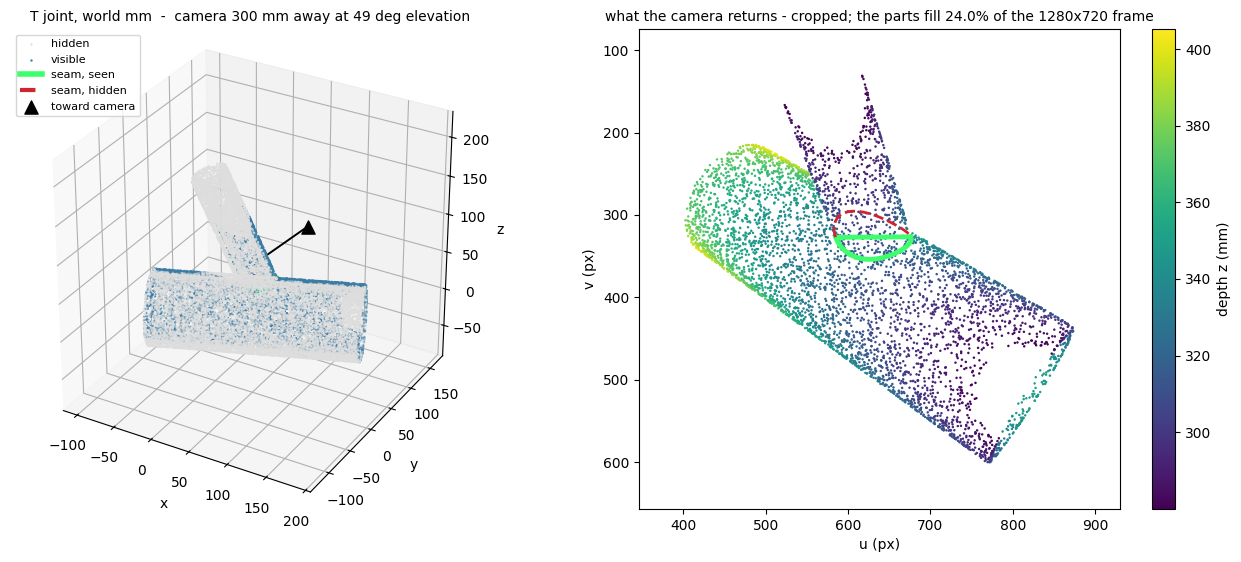

In [16]:
from weldgen.camera import project

T_cam = np.array(scene["camera"]["T_world_cam"])
K = np.array(scene["camera"]["K"])
W, H = scene["camera"]["width"], scene["camera"]["height"]

xyz = arrays["cloud.npz:xyz"]
vis = arrays["cloud.npz:visible_from_cam"]
weld = [s for s in scene["seams"]
        if s["weldable"] and s["matches_joint_type"]]
step = max(1, len(xyz) // 12000)          # thin for plotting only

fig = plt.figure(figsize=(13.5, 5.5))

# ---- world -----------------------------------------------------------------------
# The camera can be over a metre away, so it is NOT drawn to scale: including it in the
# axes shrinks a 200 mm joint to a speck. The view direction is drawn as an arrow at the
# joint instead, sized to the assembly, with the standoff stated in the title.
ax = fig.add_subplot(121, projection="3d")
ax.scatter(*xyz[~vis][::step].T, s=0.4, c="#dddddd", label="hidden")
ax.scatter(*xyz[vis][::step].T, s=0.5, c="#3a7ca5", label="visible")

for k, s in enumerate(weld):
    key = s["sampled"]["array"]           # uniform across plate and curved pipelines
    q = arrays[f"seams.npz:{key}"]
    m = arrays[f"seams.npz:{key}_visible"]
    if m.any():
        ax.plot(*q[m].T, lw=4, c="#3dff6d", label="seam, seen" if k == 0 else None)
    if (~m).any():
        ax.plot(*q[~m].T, lw=3, c="#d1242f", ls="--",
                label="seam, hidden" if k == 0 else None)

lo, hi = xyz.min(axis=0), xyz.max(axis=0)
mid, span = 0.5 * (lo + hi), float((hi - lo).max())
eye = T_cam[:3, 3]
tip = mid + (eye - mid) / np.linalg.norm(eye - mid) * span * 0.55
ax.plot(*np.column_stack([mid, tip]), lw=1.4, c="black")
ax.scatter(*tip, s=90, marker="^", c="black", label="toward camera")

for k, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
    setter(mid[k] - 0.62 * span, mid[k] + 0.62 * span)
ax.set_box_aspect([1, 1, 1])
ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f'{scene["joint"]["type"]} joint, world mm  -  camera '
             f'{scene["camera"]["standoff_mm"]:.0f} mm away at '
             f'{scene["camera"]["elevation_deg"]:.0f} deg elevation', fontsize=10)

# ---- through the lens ------------------------------------------------------------
# Zoomed to the parts, with the full sensor frame drawn dashed so you can see where in
# the image they land: at a 1 m standoff a 200 mm joint fills very little of it.
ax2 = fig.add_subplot(122)
uv, z = project(xyz, T_cam, K)
sc = ax2.scatter(uv[vis, 0], uv[vis, 1], s=0.6, c=z[vis], cmap="viridis")
fig.colorbar(sc, ax=ax2, label="depth z (mm)")
for s in weld:
    key = s["sampled"]["array"]
    q = arrays[f"seams.npz:{key}"]
    m = arrays[f"seams.npz:{key}_visible"]
    quv, _ = project(q, T_cam, K)
    ax2.plot(quv[m, 0], quv[m, 1], lw=3.5, c="#3dff6d")
    ax2.plot(quv[~m, 0], quv[~m, 1], lw=2, c="#d1242f", ls="--")

p_lo, p_hi = uv[vis].min(axis=0), uv[vis].max(axis=0)
pad = 0.12 * float((p_hi - p_lo).max())
ax2.set_xlim(p_lo[0] - pad, p_hi[0] + pad)
ax2.set_ylim(p_hi[1] + pad, p_lo[1] - pad)          # image v points down
ax2.set_aspect("equal")
ax2.set_xlabel("u (px)"); ax2.set_ylabel("v (px)")
frac = float((p_hi - p_lo).prod()) / (W * H)
ax2.set_title(f"what the camera returns - cropped; the parts fill {frac:.1%} of the "
              f"{W}x{H} frame", fontsize=10)
plt.tight_layout(); plt.show()

## Where can this seam be seen from?

The most useful plot in Phase 3: one panel per weldable seam, sweeping the camera over
azimuth × elevation on **canonical plate geometry** (this cell builds its own square-prep
plates from `JOINT` — it deliberately ignores the playground flags, curved mode included,
because the point is to isolate the camera's effect from every nuisance draw). Green
means usable.

What it shows, per joint type:

- **T** — two complementary lobes, each fillet visible from its own side (~46% each).
  The dead band is a thin stripe at azimuth 0°/180°, where the camera looks *along* the
  seam and the standing plate's near end covers the whole crease. Elevation hardly matters.
- **lap** — the lower toe is black at every pose. Not statistics: a camera above the table
  cannot see the underside of the overlap. This is why lap scenes are omitted most often.
- **butt** — the top centreline is visible everywhere; the underside one almost nowhere.
  Unequal thicknesses leave *only* the flush underside centreline, so thickness mismatch
  and visibility interact.

Change `JOINT` in the first cell and re-run to compare. (A closed curved seam — a pipe
saddle — has no per-pose all-or-nothing story at all: some arc is always visible and some
always hidden, which is what `visible_fraction` being graded rather than binary means.)

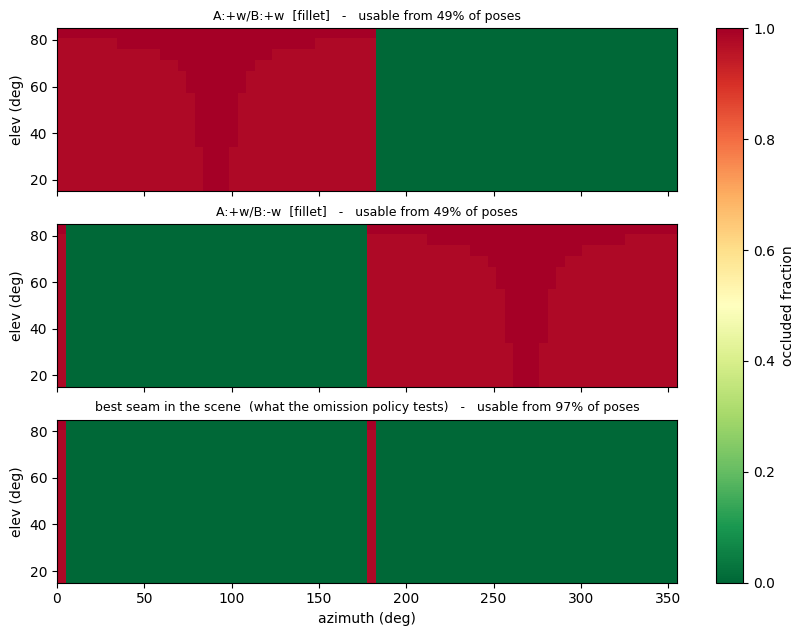

In [4]:
from weldgen.accessibility import enumerate_candidates
from weldgen.camera import intrinsics, sample_pose
from weldgen.joints import JointSpec
from weldgen.layouts import build
from weldgen.sampling import sample_polyline
from weldgen.visibility import seam_visibility

STANDOFF = 700.0

# Canonical geometry, not the sampled scene: the point is to isolate the camera's effect.
spec = JointSpec(L_A=200.0, W_A=100.0, t_A=8.0, L_B=200.0, H_B=80.0, t_B=8.0,
                 root_gap_mm=1.0, linear_misalignment_mm=0.0,
                 angular_misalignment_deg=0.0,
                 included_angle_deg=JointSpec.NOMINAL_INCLUDED_DEG[JOINT],
                 stack_offset_mm={"lap": 40.0, "edge": 0.0}.get(JOINT))
parts = build(spec, JOINT, np.eye(4))
cands = [c for c in enumerate_candidates(parts, joint_type=JOINT) if c.weldable]
Kf = intrinsics(674.0, 1280, 720)
target = np.mean([0.5 * (c.p0 + c.p1) for c in cands], axis=0)

az = np.arange(0.0, 360.0, 5.0)
el = np.arange(15.0, 86.0, 5.0)
maps = [np.zeros((len(el), len(az))) for _ in cands]
for i, e in enumerate(el):
    for j, a in enumerate(az):
        Tc = sample_pose(target, STANDOFF, e, a, 0.0)
        for k, c in enumerate(cands):
            p = sample_polyline(c.p0, c.p1, 0.25)
            v = seam_visibility(p, np.tile(c.approach, (len(p), 1)), parts,
                                Tc, Kf, 1280, 720, 280.0)
            maps[k][i, j] = 1.0 - float(v.mean())
best = np.min(maps, axis=0)

n = len(cands) + 1
fig, axes = plt.subplots(n, 1, figsize=(10, 2.4 * n), sharex=True)
axes = np.atleast_1d(axes)
for ax, grid, title in zip(
        axes,
        maps + [best],
        [f'{c.face_pair[0]}/{c.face_pair[1]}  [{c.seam_class}]' for c in cands]
        + ["best seam in the scene  (what the omission policy tests)"]):
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="RdYlGn_r",
                   vmin=0.0, vmax=1.0, extent=[az[0], az[-1], el[0], el[-1]])
    ax.set_ylabel("elev (deg)")
    ax.set_title(f"{title}   -   usable from {(grid <= 0.5).mean():.0%} of poses",
                 fontsize=9)
axes[-1].set_xlabel("azimuth (deg)")
fig.colorbar(im, ax=axes.tolist(), label="occluded fraction")
plt.show()

## The sensor model

`σ_z = subpixel · z² / (f_px · b)` — derived from stereo geometry, not fitted. The three
profiles differ only in `(baseline, focal, subpixel, min_z)`, which is what makes sensor
quality a benchmark axis rather than a constant (D16).

The noisy cloud is **not stored**: `noise.apply` is deterministic in `noise_model.seed`, so
the realisation is a convention anyone can re-run with different constants. Its dropout mask
is returned separately from `visible_from_cam`, for the reason in the header.

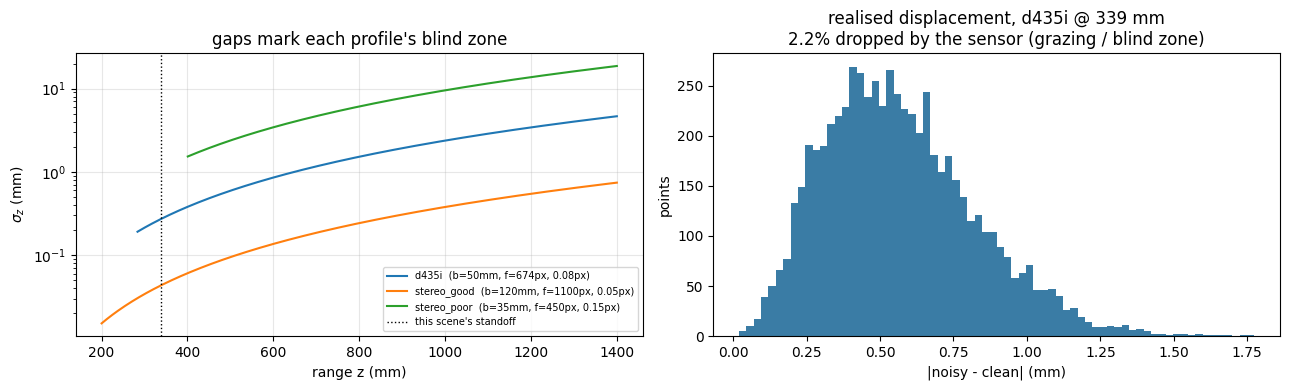

In [5]:
from weldgen.noise import apply as apply_noise
from weldgen.noise import sigma_z_mm

fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 4))
zz = np.linspace(150.0, 1400.0, 300)
for name, prof in SENSOR_PROFILES.items():
    s_ = np.where(zz < prof["min_z_mm"], np.nan, sigma_z_mm(zz, prof))
    axa.plot(zz, s_, label=f'{name}  (b={prof["baseline_mm"]:.0f}mm, '
                           f'f={prof["focal_px"]:.0f}px, {prof["subpixel_px"]}px)')
axa.axvline(scene["camera"]["standoff_mm"], ls=":", c="k", lw=1,
            label="this scene's standoff")
axa.set_xlabel("range z (mm)"); axa.set_ylabel(r"$\sigma_z$ (mm)")
axa.set_yscale("log"); axa.grid(alpha=0.3); axa.legend(fontsize=7)
axa.set_title("gaps mark each profile's blind zone")

noisy, valid = apply_noise(xyz, arrays["cloud.npz:normals"], T_cam, scene["noise_model"])
resid = np.linalg.norm(noisy - xyz, axis=1)
axb.hist(resid[vis & valid], bins=70, color="#3a7ca5")
axb.set_xlabel("|noisy - clean| (mm)"); axb.set_ylabel("points")
axb.set_title(f'realised displacement, {scene["noise_model"]["profile"]} @ '
              f'{scene["camera"]["standoff_mm"]:.0f} mm\n'
              f'{100 * (~valid).mean():.1f}% dropped by the sensor '
              f'(grazing / blind zone)')
plt.tight_layout(); plt.show()

## `area_uniform` vs `camera_raster` (D20)

`area_uniform` spreads points evenly over surface area. A depth camera does not: it returns
a pixel raster, whose surface density is `(f_px / z)²` and so falls off with the **square**
of range.

The subtlety D20 exists for: a raster only produces points where a ray *hit*, so sampling
the visible surface alone would leave the mask all-`True` and collapse `occluded_fraction`
to zero exactly when the scene is hardest. Both classes therefore come from **one** dense
pass split on the mask, which is also what keeps them rate-matched. The cost: density is
not uniform across the mask boundary, so a density-sensitive metric must be computed
*within* a class.

In [6]:
# Plate-pipeline demo on the DEFAULT config (the point is D20, not the playground
# flags). `seed` above emitted for the playground config, not necessarily for this
# one, so each mode gets its own short walk from the same start.
print(f'{"mode":<16}{"points":>10}{"density/mm2":>13}{"visible":>10}')
for mode in ("area_uniform", "camera_raster"):
    c2 = load_config()
    c2["joint_type"] = [JOINT]
    c2["sensor_profiles"] = ["d435i"]
    c2["sampling_mode"] = mode
    for s2 in range(seed, seed + 40):
        try:
            sc, ar = generate_scene(c2, s2)
            break
        except SceneRejected:
            continue
    v = ar["cloud.npz:visible_from_cam"]
    print(f'{mode:<16}{sc["cloud"]["n_points"]:>10}'
          f'{sc["cloud"]["density_per_mm2"]:>13.3f}{v.mean():>9.1%}')

mode                points  density/mm2   visible
area_uniform        241844        1.396    36.0%
camera_raster       604972        3.493    36.0%


## Yield, and how it skews the emitted mix

The omission policy is not free. It rejects a little over 40% of seeds, and **not evenly
across joint types** — so a config asking for a uniform mix does not emit one. Check this
before reading any per-class result, and rebalance by generating per type if it matters.

In [7]:
import collections

N = 60
print(f'{"joint":<8}{"kept":>6}{"hidden":>8}{"no truth":>10}{"yield":>8}')
for jt in ("T", "corner", "butt", "lap", "edge"):
    c3 = load_config()
    c3["joint_type"] = [jt]
    tally = collections.Counter()
    for s2 in range(9_900_000, 9_900_000 + N):
        try:
            generate_scene(c3, s2)
            tally["kept"] += 1
        except NoVisibleSeams:
            tally["hidden"] += 1
        except NoSeamsFound:
            tally["no truth"] += 1
    print(f'{jt:<8}{tally["kept"]:>6}{tally["hidden"]:>8}{tally["no truth"]:>10}'
          f'{tally["kept"] / N:>8.0%}')
print("\n`--n` is an attempt count, not a scene count: ask for roughly twice what you want.")

joint     kept  hidden  no truth   yield
T           38      21         1     63%
corner      23      37         0     38%
butt        36      24         0     60%
lap         14      46         0     23%
edge        28      32         0     47%

`--n` is an attempt count, not a scene count: ask for roughly twice what you want.
